### NOTE: there needs to be a data folder in this folder with the training and testing datasets. I didn't include them in the repo coz they were too heavy

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.manual_seed(67)  heehee

In [66]:
class FashionMan(nn.Module):
  def __init__(self):
    super().__init__()
    self.init_line = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 16),
        nn.ReLU()
    )
    self.left_line_one = nn.Sequential(
        nn.Linear(16, 8),
        nn.ReLU()
    )
    self.left_line_two = nn.Sequential(
        nn.Linear(8, 8),
        nn.ReLU()
    )
    self.right_line = nn.Sequential(
        nn.Linear(16, 12),
        nn.ReLU(),
        nn.Linear(12, 8),
        nn.ReLU()
    )
    self.output_line = nn.Sequential(
        nn.Linear(16, 10)
    )

  def forward(self, x):
    x = self.init_line(x)
    left_one = self.left_line_one(x)
    left_two = self.left_line_two(left_one)
    left_final = left_one + left_two
    right_final = self.right_line(x)
    output = torch.cat((left_final, right_final), dim=1)
    out = self.output_line(output)
    return out

## What I found difficult here was to type-cast everything to the correct one

In [67]:
class FashionDataset(Dataset):
  def __init__(self, data, transform=None):
    self.transform = transform
    self.y = data.iloc[:, 0].values
    self.x = data.iloc[:, 1:].values.astype('uint8').reshape(-1, 28, 28) # Can have extra param for b/w

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    image = self.x[idx]
    label = self.y[idx]
    if self.transform:
      image = self.transform(image)
    return image, label

def normalize_and_tensor(mean, std):
  transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((mean,), (std,)),
  ])
  return transform

In [68]:
train_data_raw = pd.read_csv('data/fashion-mnist_train.csv')

data = train_data_raw.iloc[:, 1:].values / 255.0
mean = data.mean()
std = data.std()
transform = normalize_and_tensor(mean, std)

train_data = FashionDataset(train_data_raw, transform=transform)

train_data, val_data = random_split(train_data, [int(len(train_data) * 0.85), int(len(train_data) * 0.15)])

train_data_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_data_loader = DataLoader(val_data, batch_size=64, shuffle=False)

In [69]:
model = FashionMan().to(device)
cross_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## I tried both adam and sgd. I learnt that a lower learning rate for adam works better coz it automatically reduces step size. A learning rate of `0.1` for SGD game somewhat similar results.

In [70]:
training_losses = []
validation_losses = []
training_accuracies = []
validation_accuracies = []

raw_training_losses = []
raw_validation_losses = []

In [71]:
epochs = 13
for e in range(epochs):

  training_loss = 0.0
  correct_pred = 0
  total_no = 0

  model.train()
  for X, y in train_data_loader:
    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    loss = cross_loss(y_pred, y)
    training_loss += loss.item()
    raw_training_losses.append(loss.item())

    # torch.max finds which label has the maximum percentage confidence.
    # The predicted just gave the labels, and torch.max also returned the other values
    # Since I didn't need the other values I put _
    # I used this same logic everywhere for predictions
    _, predicted = torch.max(y_pred.data, 1)
    total_no += y.size(0)
    correct_pred += (predicted == y).sum().item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  training_losses.append(training_loss / len(train_data_loader))
  training_accuracies.append(correct_pred * 100 / total_no)

  print(f'Epoch: {e+1} with Loss: {training_loss / len(train_data_loader)}')

  model.eval()
  testing_loss = 0.0
  correct_pred = 0
  total_no = 0

  with torch.inference_mode():
    for X, y in val_data_loader:
      X = X.to(device)
      y = y.to(device)

      y_pred = model(X)
      loss = cross_loss(y_pred, y)
      testing_loss += loss.item()
      raw_validation_losses.append(loss.item())

      _, predicted = torch.max(y_pred.data, 1)
      total_no += y.size(0)
      correct_pred += (predicted == y).sum().item()

    validation_losses.append(testing_loss / len(val_data_loader))
    validation_accuracies.append(correct_pred * 100 / total_no)

  print(f'Test Loss: {testing_loss / len(val_data_loader)}')
  print(f'Test Accuracy: {correct_pred / total_no}')

Epoch: 1 with Loss: 0.6365383846996121
Test Loss: 0.49497758877192827
Test Accuracy: 0.8243333333333334
Epoch: 2 with Loss: 0.43940416808559124
Test Loss: 0.4423308440134035
Test Accuracy: 0.8402222222222222
Epoch: 3 with Loss: 0.40541235711822843
Test Loss: 0.40627202687534036
Test Accuracy: 0.8553333333333333
Epoch: 4 with Loss: 0.3853446592201702
Test Loss: 0.4137306248253964
Test Accuracy: 0.8514444444444444
Epoch: 5 with Loss: 0.3713693084520109
Test Loss: 0.3850639505800626
Test Accuracy: 0.8621111111111112
Epoch: 6 with Loss: 0.35962340338541243
Test Loss: 0.3942293592378603
Test Accuracy: 0.8592222222222222
Epoch: 7 with Loss: 0.34921665145656844
Test Loss: 0.3984740473699908
Test Accuracy: 0.8607777777777778
Epoch: 8 with Loss: 0.3432239586933793
Test Loss: 0.37192450611726613
Test Accuracy: 0.867
Epoch: 9 with Loss: 0.3348708889509085
Test Loss: 0.37910780913018166
Test Accuracy: 0.8661111111111112
Epoch: 10 with Loss: 0.32921851281464626
Test Loss: 0.3672885254342505
Test Ac

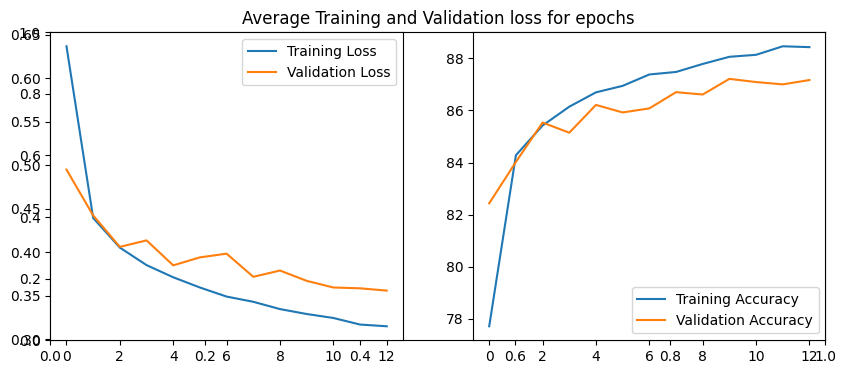

Final Training Loss: 0.3151253116138307
Final Validation Loss: 0.3560675010085106
Final Training Accuracy: 88.43%
Final Validation Accuracy: 87.17%


In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.title('Average Training and Validation loss for epochs')

plt.subplot(1, 2, 1)
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_accuracies, label='Training Accuracy')
plt.plot(validation_accuracies, label='Validation Accuracy')
plt.legend()

plt.show()

print(f'Final Training Loss: {training_losses[-1]}')
print(f'Final Validation Loss: {validation_losses[-1]}')
print(f'Final Training Accuracy: {training_accuracies[-1]:.2f}%')
print(f'Final Validation Accuracy: {validation_accuracies[-1]:.2f}%')

## My inference is that the peaks in loss and dips in accuracies represent overfitting

In [73]:
results = []
test_data_raw = pd.read_csv('./data/fashion-mnist_test.csv')
test_data = FashionDataset(test_data_raw, transform=transform)
test_data_loader = DataLoader(test_data, batch_size=64, shuffle=False)
model.eval()
with torch.inference_mode():
    for X, y in test_data_loader:
      X = X.to(device)
      y_pred = model(X)
      _, predicted = torch.max(y_pred.data, 1)
      results.extend(predicted.tolist())

print(results)

[0, 1, 2, 0, 3, 6, 8, 4, 5, 0, 3, 4, 2, 6, 8, 5, 4, 3, 6, 4, 4, 4, 2, 1, 5, 9, 8, 4, 4, 1, 7, 7, 7, 8, 1, 0, 9, 8, 6, 8, 2, 0, 4, 4, 2, 0, 3, 3, 2, 3, 2, 4, 9, 3, 0, 9, 9, 4, 0, 0, 4, 5, 4, 6, 1, 1, 0, 9, 5, 2, 7, 3, 4, 0, 5, 7, 1, 6, 1, 0, 9, 8, 1, 2, 4, 8, 9, 4, 1, 6, 3, 6, 4, 2, 6, 4, 4, 7, 7, 3, 9, 6, 9, 6, 8, 2, 3, 8, 2, 7, 5, 5, 4, 4, 7, 5, 6, 2, 7, 4, 0, 5, 4, 4, 7, 0, 8, 5, 0, 3, 1, 7, 9, 4, 9, 6, 4, 6, 6, 4, 3, 3, 3, 2, 2, 6, 3, 0, 1, 3, 4, 3, 3, 1, 9, 3, 3, 3, 9, 5, 6, 7, 7, 3, 2, 4, 0, 6, 7, 2, 2, 8, 9, 0, 2, 4, 6, 5, 7, 9, 7, 1, 3, 9, 1, 5, 5, 6, 0, 7, 4, 9, 1, 6, 0, 0, 6, 4, 0, 9, 0, 4, 4, 5, 5, 8, 6, 2, 1, 9, 3, 4, 7, 1, 9, 5, 9, 0, 2, 8, 5, 7, 7, 3, 2, 4, 5, 9, 8, 1, 9, 5, 6, 2, 9, 7, 2, 0, 9, 2, 1, 5, 7, 7, 0, 2, 4, 5, 3, 3, 8, 1, 6, 4, 4, 8, 4, 9, 8, 3, 3, 2, 4, 4, 2, 9, 3, 9, 2, 8, 6, 8, 8, 2, 7, 2, 5, 5, 9, 7, 8, 6, 4, 8, 3, 8, 3, 1, 2, 2, 2, 1, 8, 1, 3, 0, 3, 1, 7, 0, 5, 2, 0, 9, 6, 2, 7, 4, 7, 7, 1, 0, 6, 0, 7, 8, 7, 0, 9, 2, 0, 2, 5, 0, 8, 5, 8, 7, 7, 6, 1, 2, 9, 

In [ ]:
original = test_data_raw.iloc[:, 0].values
df = pd.DataFrame({'real': original, 'predicted': results})
df.to_csv('../submissions.csv', index=False)

### I tried to show where it makes mistakes, usually in large pullovers and thin dresses

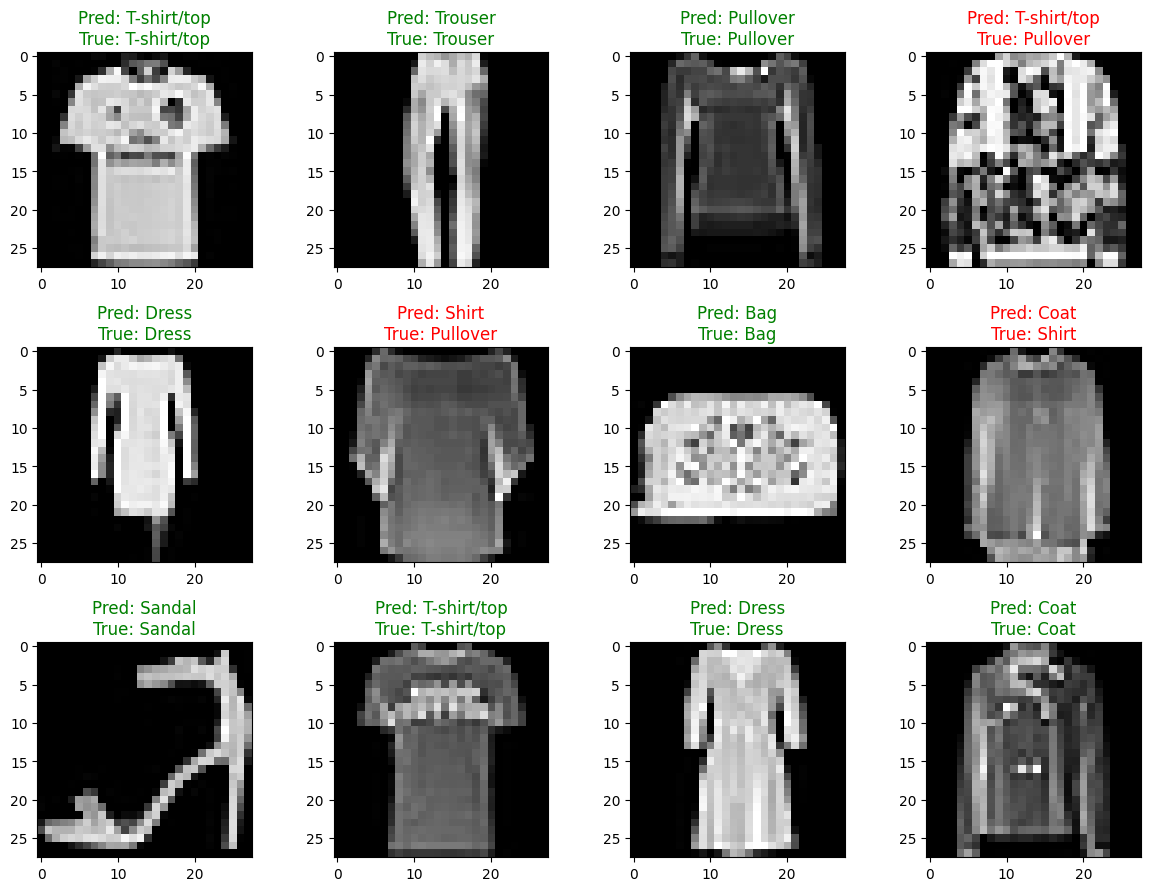

In [75]:
fashion_classes = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

# I tried using test_data_loader[0] by mistake at first
dataiter = iter(test_data_loader)
images, labels = next(dataiter)

predicted = results[:12]

fig = plt.figure(figsize=(12, 9))
for idx in range(12):
    subplot = fig.add_subplot(3, 4, idx + 1)

    img = images[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')

    pred_name = fashion_classes[predicted[idx]]
    true_name = fashion_classes[labels[idx].item()]
    correct = pred_name == true_name

    title_color = 'green' if correct else 'red'
    subplot.set_title(f"Pred: {pred_name}\nTrue: {true_name}", color=title_color)

plt.tight_layout()
plt.show()

### The learning resources say torch.save, but since the pdf says to use pickle, I'm going with pickle

In [ ]:
import pickle
weights = model.state_dict()
f = open('../saved_models/nn_weights.pkl', 'wb')
pickle.dump(weights, f)
f.close()

In [77]:
print(torch.initial_seed())

17399050175233691180
